In [1]:
import geopandas as gpd
import pandas
from polars import quantile
from pyproj import Transformer
from requests import get, post
import pandas as pd
from shapely.geometry import Polygon, Point, MultiPolygon
import numpy as np

In [110]:
zoning_map = get('https://mapsa.slocity.org/hosting/rest/services/sloGISlayers/gisLandManagementWM/MapServer/5/query?where=1%3D1&f=pjson').json()


zones = pd.json_normalize(zoning_map['features'])
zones = zones.explode(column='geometry.rings')


arcgis_to_lat_log = Transformer.from_crs("EPSG:3857", "EPSG:4326")

zones['polygon'] = zones['geometry.rings'].map(lambda x: [arcgis_to_lat_log.transform(point[0], point[1])[::-1] for point in x])

zones = gpd.GeoDataFrame(zones['attributes.generalZone'].rename('zone'), geometry=zones['polygon'].map(Polygon))

del zoning_map
zones

,zone,geometry
0,R-1,"POLYGON ((-120.62803 35.26558, -120.62803 35.2..."
1,C/OS,"POLYGON ((-120.69361 35.31137, -120.69368 35.3..."
2,R-1,"POLYGON ((-120.64883 35.29331, -120.64884 35.2..."
3,R-1,"POLYGON ((-120.64659 35.29492, -120.64658 35.2..."
4,R-1,"POLYGON ((-120.64769 35.29465, -120.64769 35.2..."
...,...,...
1320,R-1,"POLYGON ((-120.63247 35.25076, -120.63251 35.2..."
1321,PF,"POLYGON ((-120.63378 35.2519, -120.63386 35.25..."
1322,R-1,"POLYGON ((-120.63309 35.25242, -120.63318 35.2..."
1323,PF,"POLYGON ((-120.63377 35.25326, -120.63381 35.2..."


In [7]:
license_data = pd.read_csv('./licenses_with_locs.txt')
license_data.head()

,DBA,Business type,Bus address,"Bus City, State",Start date,Close date,Account #,Owner Name 1,License description,Rate type (STD),type,long,lat,closure_time,censor
0,!ROMP,Apparel/Accessories,714 HIGUERA ST,"SAN LUIS OBISPO, CA 93401-3513",2005-04-06,2019-05-03,16453,"English, Karen",NaN,Downtown Association,Downtown Association,-120.664277,35.279094,7639,1
1,"""""""Angel Lynn""""""",Misc Business Services,3860 S HIGUERA ST SP A24,"SAN LUIS OBISPO, CA 93401-7460",2009-06-08,2012-01-01,107052,"Block, Fay","Face Painting, Balloon Sculpture, Card Tricks,...",General Service,Service,-120.673262,35.247583,6115,1
2,"""""""Slack""""""",Rental- Residential,2045 SLACK ST,"SAN LUIS OBISPO, CA 93405-2107",2009-10-28,2017-04-20,107394,"Scheel Larsen, Anne",Residential Property Rental,Residential Rental,Rental,-120.650013,35.295909,5973,1
3,@ BITES,Restaurant,195 N SANTA ROSA ST,"SAN LUIS OBISPO, CA 93405-1322",2021-04-05,NaN,117190,"Le, Phuong",Fast Food Restaurant,General Retailer,Retail,-120.669502,35.295490,1796,0
4,@ Nails,Beauty Salon,1519 FROOM RANCH WAY STE A BLDG E,"SAN LUIS OBISPO, CA 93405-7211",2008-01-23,NaN,106088,"Nguyen, Kieutrinh",Nail Salon,General Service,Service,-120.687969,35.252327,6617,0


In [11]:
def get_zone(point : Point):
    return None if point == Point(np.nan,np.nan) else zones.iloc[zones.distance(point).idxmin()]['zone']

get_zone(Point(license_data['long'][0], license_data['lat'][0]))

'C-D'

In [13]:
license_data['zone'] = license_data[['long','lat']].apply(lambda x: Point(x),axis=1).map(get_zone)

In [111]:
offset = 0

data = pd.DataFrame()
while True:
    offset = len(data)
    new_data = pd.json_normalize(get(f'https://mapsa.slocity.org/hosting/rest/services/sloGISlayers/gisLandManagementWM/MapServer/4/query?where=1%3D1&f=pjson&resultOffset={offset}').json()['features'])
    data  = pd.concat([data, new_data]).reset_index(drop=True)
    if new_data.empty:
        break

parcels = gpd.GeoDataFrame(geometry=data['geometry.rings'].map(lambda x: [arcgis_to_lat_log.transform(point[0], point[1])[::-1] for point in x[0]]).map(Polygon)) # Convert points to shape objects

parcels['APN'] = data['attributes.APN']

del new_data
del data

def get_parcel(point : Point):
    return None if point == Point(np.nan,np.nan) else parcels['APN'][parcels.distance(point).idxmin()]

parcels

,geometry,APN
0,"POLYGON ((-120.67176 35.28901, -120.67176 35.2...",001-012-006
1,"POLYGON ((-120.67206 35.28854, -120.67229 35.2...",001-012-008
2,"POLYGON ((-120.67206 35.28854, -120.67212 35.2...",001-012-009
3,"POLYGON ((-120.67255 35.29033, -120.67255 35.2...",001-012-012
4,"POLYGON ((-120.67234 35.29033, -120.67234 35.2...",001-012-013
...,...,...
17326,"POLYGON ((-120.64412 35.26909, -120.64428 35.2...",004-785-011
17327,"POLYGON ((-120.64347 35.26948, -120.64373 35.2...",004-785-001
17328,"POLYGON ((-120.66348 35.27232, -120.66348 35.2...",003-623-002
17329,"POLYGON ((-120.64737 35.29002, -120.64757 35.2...",001-251-034


In [17]:
get_parcel(Point(license_data['long'][0], license_data['lat'][0]))

'002-423-013'

In [18]:
license_data['parcel'] = license_data[['long','lat']].apply(lambda x: Point(x),axis=1).map(get_parcel)

# Getting APN Details

In [131]:
sizes = parcels.set_crs("EPSG:4326").to_crs("EPSG:6933").area * (3.28084 **2) # Convert from Square Meters to Square Feet
sizes = sizes.to_frame()
sizes = sizes.rename({0:'sq(ft)'},axis=1)
sizes['APN'] = parcels['APN']
sizes.head()

,sq(ft),APN
0,9156.469016,001-012-006
1,5643.596509,001-012-008
2,6722.052896,001-012-009
3,6817.425448,001-012-012
4,6833.958972,001-012-013


In [142]:
pd.merge(license_data, sizes, left_on='parcel', right_on='APN', how='inner').drop('APN', axis=1).to_csv('licenses_w_lot_size.txt')

In [2]:
license_data = pd.read_csv('licenses_w_lot_size.txt')

In [3]:
license_data['is_downtown_association'] = (license_data['zone'] == 'C-D')

In [4]:
license_data.drop(['Account #', 'Owner Name 1'],axis=1, inplace=True)

In [37]:
zone_mappings = {
    'R-1' : 'Residential',
    'R-2' : 'Residential',
    'R-3' : 'Residential',
    'R-4' : 'Residential',
    'C' : 'Commercial',
    'BP' : "Commercial",
    'PF' : "Public",
    'O' : 'Office',
    'M' : 'Manufacturing',
}

license_data['zone_type'] = license_data['zone'].map(zone_mappings)

In [45]:
license_data['is_home_occ'] =  license_data['Business type'].str.contains('Home Occ').fillna(False)

C:\Users\curti\AppData\Local\Temp\ipykernel_12688\1750331633.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  license_data['is_home_occ'] =  license_data['Business type'].str.contains('Home Occ').fillna(False)


In [47]:
license_data.to_csv('Cleaned_data.csv', index=False)

In [69]:
filtered_licenses = license_data[~(license_data['Business type'].str.contains('Rental').fillna('False').astype(bool) | license_data['Business type'].str.contains('Homestay').fillna('False').astype(bool))]

In [75]:
filtered_licenses[~filtered_licenses['is_home_occ']]['Business type'].value_counts()

Business type
Retail                                     1004
Medical Services                            583
Beauty Salon                                540
Restaurant                                  478
Personal Services                           350
                                           ... 
Cannabis - Transporter                        1
Real Estate Business Based Outside City       1
Cannabis - Retail                             1
Appraiser                                     1
Taxi                                          1
Name: count, Length: 103, dtype: int64

In [76]:
license_data

,DBA,Business type,Bus address,Start date,Close date,License description,Rate type (STD),type,long,lat,closure_time,censor,zone,parcel,sq(ft),is_downtown_association,zone_type,is_home_occ
0,!ROMP,Apparel/Accessories,714 HIGUERA ST,2005-04-06,2019-05-03,NaN,Downtown Association,Downtown Association,-120.664277,35.279094,7639,1,C,002-423-013,4.909187e+03,True,Commercial,False
1,"""""""Angel Lynn""""""",Misc Business Services,3860 S HIGUERA ST SP A24,2009-06-08,2012-01-01,"Face Painting, Balloon Sculpture, Card Tricks,...",General Service,Service,-120.673262,35.247583,6115,1,R-2,053-131-011,1.040694e+06,False,Residential,False
2,"""""""Slack""""""",Rental- Residential,2045 SLACK ST,2009-10-28,2017-04-20,Residential Property Rental,Residential Rental,Rental,-120.650013,35.295909,5973,1,R-1,052-124-010,6.569625e+03,False,Residential,False
3,@ BITES,Restaurant,195 N SANTA ROSA ST,2021-04-05,NaN,Fast Food Restaurant,General Retailer,Retail,-120.669502,35.295490,1796,0,C,052-332-041,1.510382e+04,False,Commercial,False
4,@ Nails,Beauty Salon,1519 FROOM RANCH WAY STE A BLDG E,2008-01-23,NaN,Nail Salon,General Service,Service,-120.687969,35.252327,6617,0,C,053-510-016,3.849968e+05,False,Commercial,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15328,Zoric Logistics LLC,Home Occupation,994 BLUEBELL WAY,2021-10-06,2025-08-11,Transportation & Delivery of Goods,General Service,Service,-120.636923,35.249175,1612,1,R-2,053-080-033,1.863355e+05,False,Residential,True
15329,Zs Unlimited,Auto Mechanic/Detailer/Services,3621 SACRAMENTO DR 6,1993-06-25,2007-11-27,NaN,General Service,Service,-120.641378,35.254683,11942,1,M,053-231-025,1.454382e+05,False,Manufacturing,False
15330,Zube's Import Auto Sales,Retail,225 TANK FARM RD STE B2,2009-10-28,NaN,Retail Used Auto Sales - Max Of 5 Cars Display...,General Retailer,Retail,-120.667644,35.246746,5973,0,C,053-258-012,2.609308e+05,False,Commercial,False
15331,Zumer Products Llc,"Wholesale, Distributors",3563 SUELDO ST Q,2000-08-10,2009-10-21,NaN,General Wholesaler,Other,-120.665576,35.251453,9339,1,C,053-253-036,8.564002e+04,False,Commercial,False


In [167]:
params = {
    "where": "1=1",
    "outFields": "*",
    "returnGeometry": "true",
    "f": "pjson",
    "outSR": "4326",
}

query = get('https://mapsa.slocity.org/hosting/rest/services/sloGISlayers/gisLandManagementWM/MapServer/25/query',
                           params=params)

downtown_association = query.json()['features'][0]['geometry']['rings'][0]
downtown_association = Polygon(downtown_association)



pts = gpd.GeoDataFrame(
    license_data.copy(),
    geometry=gpd.points_from_xy(license_data["long"], license_data["lat"]),
    crs="EPSG:4326"
)


poly_gdf = gpd.GeoDataFrame(geometry=[downtown_association],crs="EPSG:4326")


pts_f  = pts.to_crs("EPSG:2229")
poly_f = poly_gdf.to_crs("EPSG:2229")
license_data['ft to downtown'] = pts_f.geometry.distance(poly_f.geometry.iloc[0])

<Axes: ylabel='Frequency'>

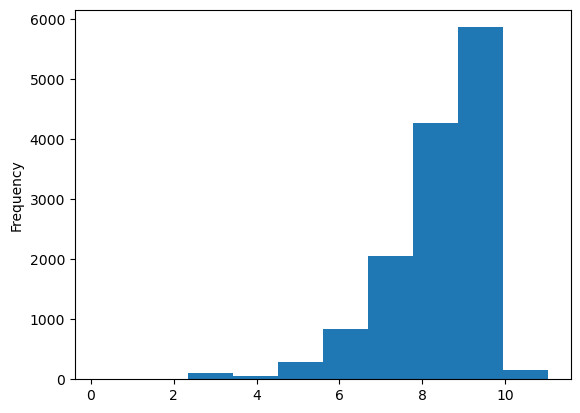

In [182]:
license_data['ft to downtown'].apply(np.log).fillna(0).where(lambda x: x != -np.inf).dropna().plot.hist()

In [1]:
license_data.sort_index().to_csv('licenses_w_dist.txt',index=False)

license_data

NameError: name 'license_data' is not defined

In [2]:
import pandas as pd
import datetime
import geopandas as gpd
from shapely import from_wkt
import tqdm

tqdm.tqdm.pandas()

data=  pd.read_csv('../BLSurvival.txt')
data2 = pd.read_csv('new_process.txt').rename({'500m_10yr_churn' : '500m_5yr_churn'}, axis=1)
data2['start_year'] = pd.to_datetime(data2['Start date']).dt.year


diff =  (datetime.datetime.now() - pd.to_datetime(data2['Start date'])).dt.days
diff2 =  (pd.to_datetime(data2['Close date']) - pd.to_datetime(data2['Start date'])).dt.days


data2['closure_time'] = diff2.fillna(diff)


data2 = data2[~data2['Business type'].isna()]

data2['start_year'] > 2003

data2 = data2.drop_duplicates()


data2['Rate type (STD)'].value_counts()

data2['geometry'] = data2['geometry'].apply(from_wkt)

gdf = gpd.GeoDataFrame(data2, crs='EPSG:4326').to_crs(epsg=3395)

In [4]:


distance = 500


def num_businesses(p1):

    nearby = gdf[gdf.distance(p1.geometry) < distance]

    nearby = nearby[pd.to_datetime(nearby['Start date']) < pd.to_datetime(p1['Start date'])]

    return nearby[~(pd.to_datetime(nearby['Close date']) < pd.to_datetime(p1['Start date']))].count()

num_bus = gdf.progress_apply(num_businesses, axis=1)

100%|██████████| 11219/11219 [02:47<00:00, 67.15it/s]


In [9]:
gdf['businesses_within_500m'] = num_bus['DBA']

In [47]:
gdf.sort_values(by='businesses_within_500m', ascending=False)
gdf = gdf[~(pd.to_datetime(gdf['Close date']).dt.year > 2025)]

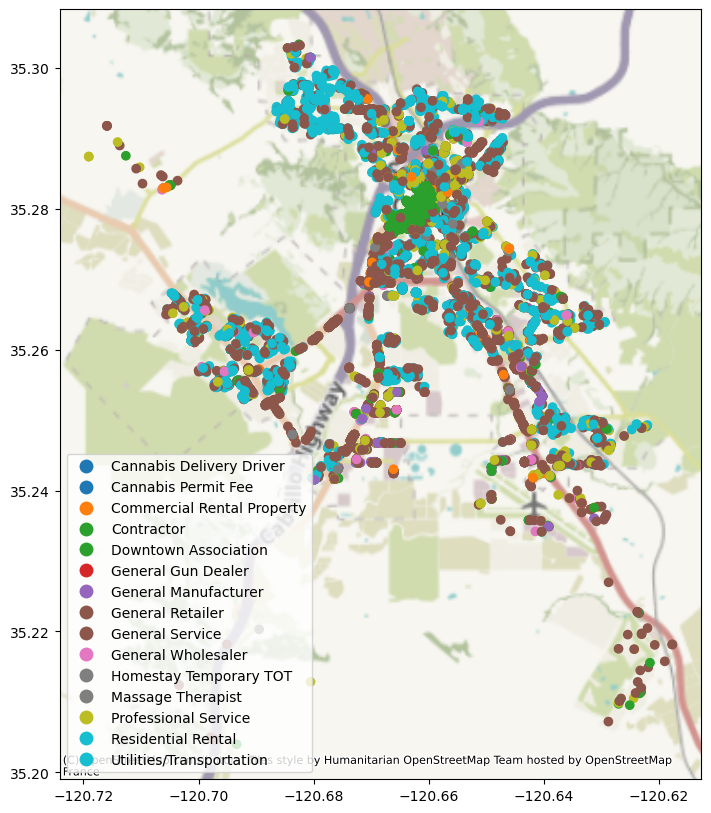

In [25]:
import contextily as cx


ax = gdf.to_crs("EPSG:4326").plot(column='Rate type (STD)',legend=True,figsize=(10,10))
cx.add_basemap(ax, crs="EPSG:4326", zoom=12)


<Axes: xlabel='Close date'>

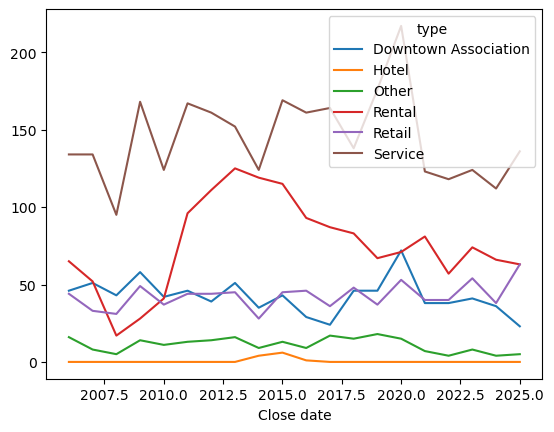

In [53]:
close_year = pd.to_datetime(gdf['Close date']).dt.year.to_frame()
close_year['type'] = gdf['type']
close_year = close_year[close_year['Close date'] > 2005]
close_year.dropna().groupby('type').value_counts().reset_index().pivot(values='count',index='Close date',columns='type').fillna(0).plot.line()

In [81]:
gdf[cols].to_csv('BLSurvival.txt',index=False)